In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#Load Dataset

In [4]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"] = housing.target

In [5]:
#Select one feature

In [6]:
x =  data[['AveRooms']].values
y = data['Price'].values

In [7]:
#Split Data

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size = 0.3,
    random_state = 38
)

In [9]:
#Feature Scaling

In [10]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [11]:
w = 0
b = 0

learning_rate = 0.001
epochs = 1000

n = len(x_train_scaled)
cost_history = []
for i in range(epochs):
    y_pred = w * x_train_scaled.flatten() + b
    dw = (1/n) * np.sum((y_pred - y_train) * x_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    cost = (1/(2*n)) * np.sum((y_pred - y_train)**2)
    cost_history.append(cost)
    
    if i % 100 ==0:
        print(f"Epoch {i}, Cost = {cost:.4f}")
        

y_pred_gd = w* x_test_scaled.flatten()+b

Epoch 0, Cost = 2.8292
Epoch 100, Cost = 2.4355
Epoch 200, Cost = 2.1132
Epoch 300, Cost = 1.8493
Epoch 400, Cost = 1.6333
Epoch 500, Cost = 1.4565
Epoch 600, Cost = 1.3117
Epoch 700, Cost = 1.1932
Epoch 800, Cost = 1.0961
Epoch 900, Cost = 1.0167


In [12]:
print("Gradient Descent")
print("----------------")
print("Weight: ",w)
print("Bias: ",b)
print("MSE: ", mean_squared_error(y_test,y_pred_gd))
print("R2 Score: ", r2_score(y_test, y_pred_gd))

Gradient Descent
----------------
Weight:  0.10039794701917998
Bias:  1.3137544174341393
MSE:  1.815083583201694
R2 Score:  -0.3881141422787311


In [13]:
#Normal Equation

In [14]:
x_train_ne = np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne = np.c_[np.ones((len(x_test),1)),x_test]

theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train
y_pred_ne = x_test_ne @ theta

In [15]:
print("\nNormal Equation")
print("-----------------")
print("Intercept: ", theta[0])
print("Slope: ", theta[1])
print("MSE: ", mean_squared_error(y_test, y_pred_ne))
print("R2_score: ", r2_score(y_test,y_pred_ne))


Normal Equation
-----------------
Intercept:  1.7455984245475227
Slope:  0.06117291721394639
MSE:  1.2667893986046186
R2_score:  0.03120258716127733


In [16]:
#Sort Values for smooth regression lines

In [17]:
sort_axis = np.argsort(x_test.flatten())
x_sorted = x_test[sort_axis]
y_pred_ne_sorted = y_pred_ne[sort_axis]

In [18]:
#Regression Line Visualization
#Sort x values for a smooth line

In [19]:
index = np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [20]:
#Scatter plot

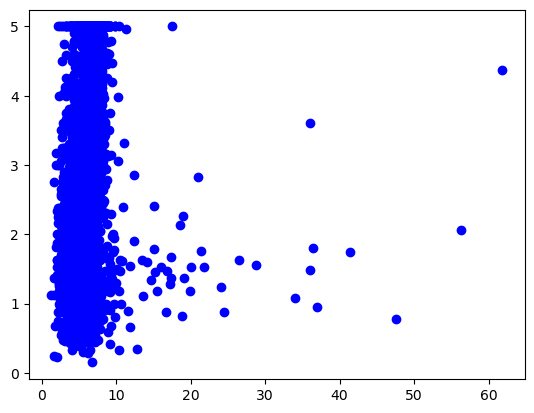

In [21]:
plt.scatter(x_test,y_test, color = 'blue', label = 'Actual Data')

In [22]:
#Regression Line

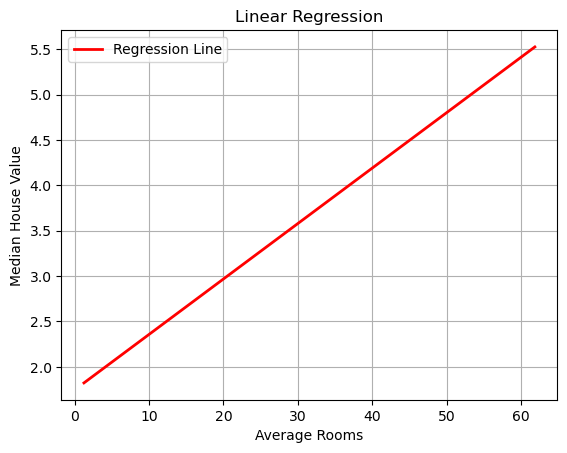

In [23]:
plt.plot(
    x_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
#Cost Convergence Curve

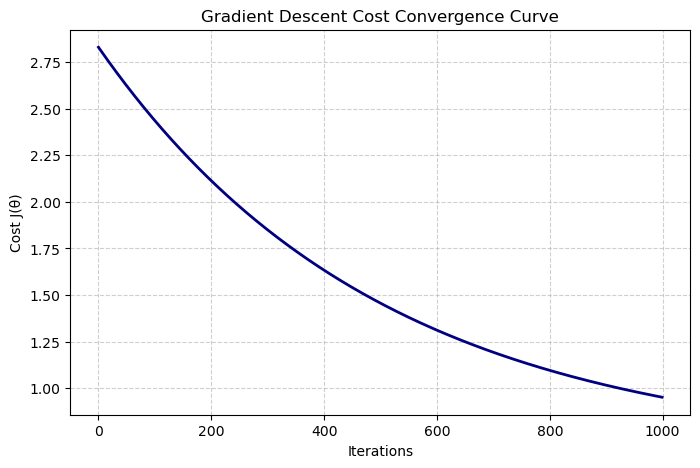

In [25]:
plt.figure(figsize=(8,5))

plt.plot(cost_history, color= 'navy', linewidth=2)

plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel("Cost J(θ)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()